In [67]:
import pandas as pd
df = pd.read_csv("Dummy Data HSS.csv")
print(df.head())

     TV      Radio  Social Media Influencer       Sales
0  16.0   6.566231      2.907983       Mega   54.732757
1  13.0   9.237765      2.409567       Mega   46.677897
2  41.0  15.886446      2.913410       Mega  150.177829
3  83.0  30.020028      6.922304       Mega  298.246340
4  15.0   8.437408      1.405998      Micro   56.594181


In [68]:
import pandas as pd

# Load dataset
df = pd.read_csv("Dummy Data HSS.csv")

# 1. Handle Missing Values
# Option 1: drop rows with missing values
df = df.dropna()

# (OR if you want to fill instead)
# df = df.fillna(df.mean(numeric_only=True))

# 2. Remove Duplicates
df = df.drop_duplicates()

# 3. Convert Categorical Data to Numerical
# Automatically convert all object (text) columns
df = pd.get_dummies(df, drop_first=True)

# Show cleaned data
print(df.head())

# Save cleaned dataset
df.to_csv("cleaned_data.csv", index=False)

     TV      Radio  Social Media       Sales  Influencer_Mega  \
0  16.0   6.566231      2.907983   54.732757             True   
1  13.0   9.237765      2.409567   46.677897             True   
2  41.0  15.886446      2.913410  150.177829             True   
3  83.0  30.020028      6.922304  298.246340             True   
4  15.0   8.437408      1.405998   56.594181            False   

   Influencer_Micro  Influencer_Nano  
0             False            False  
1             False            False  
2             False            False  
3             False            False  
4              True            False  


In [69]:
import pandas as pd

# Load dataset
df = pd.read_csv("Dummy Data HSS.csv")

# 1. Handle Missing Values
# Option 1: drop rows with missing values
df = df.dropna()

# (OR if you want to fill instead)
# df = df.fillna(df.mean(numeric_only=True))

# 2. Remove Duplicates
df = df.drop_duplicates()

# 3. Convert Categorical Data to Numerical
# Automatically convert all object (text) columns
df = pd.get_dummies(df, drop_first=True)

# Show cleaned data
print(df.head())

# Save cleaned dataset
df.to_csv("cleaned_data.csv", index=False)

     TV      Radio  Social Media       Sales  Influencer_Mega  \
0  16.0   6.566231      2.907983   54.732757             True   
1  13.0   9.237765      2.409567   46.677897             True   
2  41.0  15.886446      2.913410  150.177829             True   
3  83.0  30.020028      6.922304  298.246340             True   
4  15.0   8.437408      1.405998   56.594181            False   

   Influencer_Micro  Influencer_Nano  
0             False            False  
1             False            False  
2             False            False  
3             False            False  
4              True            False  


In [70]:
from sklearn.model_selection import train_test_split

# Define X and Y
X = df.drop("Sales", axis=1)
y = df["Sales"]

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check sizes
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3636, 6)
Testing set size: (910, 6)


In [71]:
from sklearn.preprocessing import StandardScaler

# Apply scaling only on numerical features
scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show sample before and after
print("Before Scaling (first row):")
print(X_train.iloc[0])

print("\nAfter Scaling (first row):")
print(X_train_scaled[0])

Before Scaling (first row):
TV                       96.0
Radio               33.737174
Social Media         8.701501
Influencer_Mega         False
Influencer_Micro         True
Influencer_Nano         False
Name: 566, dtype: object

After Scaling (first row):
[ 1.60426873  1.60708463  2.44575014 -0.5845489   1.72824828 -0.57607997]


Original shape: (4572, 7)
After removing outliers: (4543, 7)

Model Comparison:

                   Model        MSE        R2
0      Linear Regression  47.811300  0.994463
1  Polynomial Regression  48.890486  0.994338
2                  Ridge  47.810097  0.994464
3                  Lasso  47.385053  0.994513
4            Elastic Net  47.370511  0.994515

Best Model:
 Model    Elastic Net
MSE        47.370511
R2          0.994515
Name: 4, dtype: object

Linear Regression Equation:
Intercept: -0.549661658191809
Coefficients: [3.51251905 0.11528454 0.13387603 0.69207552 0.66999167 0.55072508]


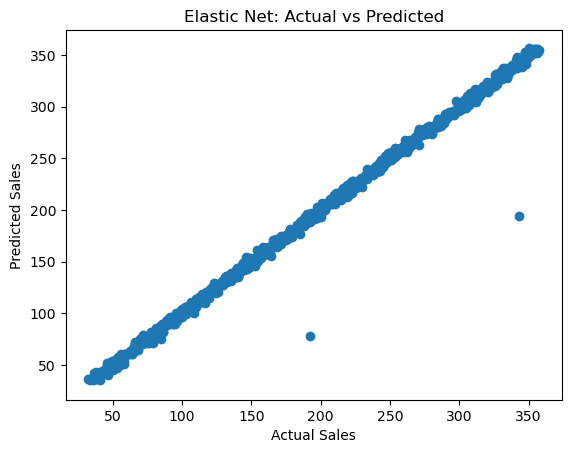

In [72]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# =========================
# 1. Load & Preprocess Data
# =========================

df = pd.read_csv("Dummy Data HSS.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert categorical variable
df = pd.get_dummies(df, columns=["Influencer"], drop_first=True)

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# =========================
# 2. Remove Outliers (IQR)
# =========================

# Select only numeric columns (exclude boolean)
numeric_df = df.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter using numeric columns only
filter_mask = ~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

df_clean = df[filter_mask]

print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

# =========================
# 3. Split Data
# =========================

X = df_clean.drop("Sales", axis=1)
y = df_clean["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. Apply Models
# =========================

models = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
models["Linear Regression"] = lr.predict(X_test)

# Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
models["Polynomial Regression"] = pr.predict(X_test_poly)

# Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
models["Ridge"] = ridge.predict(X_test)

# Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
models["Lasso"] = lasso.predict(X_test)

# Elastic Net
elastic = ElasticNet()
elastic.fit(X_train, y_train)
models["Elastic Net"] = elastic.predict(X_test)

# =========================
# 5. Evaluate Models
# =========================

results = []

for name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
print("\nModel Comparison:\n")
print(results_df)

# =========================
# 6. Best Model
# =========================

best_model = results_df.loc[results_df["R2"].idxmax()]
print("\nBest Model:\n", best_model)

# =========================
# 7. Regression Equation
# =========================

print("\nLinear Regression Equation:")
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

# =========================
# 8. Visualization
# =========================

best_name = best_model["Model"]
y_pred_best = models[best_name]

plt.figure()
plt.scatter(y_test, y_pred_best)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"{best_name}: Actual vs Predicted")
plt.show()

In [73]:
sample_5 = df_clean.sample(n=5, random_state=1)

print(sample_5[[
    "TV",
    "Radio",
    "Social Media",
    "Influencer_Mega",
    "Influencer_Micro",
    "Influencer_Nano",
    "Sales"
]])

        TV      Radio  Social Media  Influencer_Mega  Influencer_Micro  \
3035  57.0  13.280603      2.101510             True             False   
1080  28.0  10.372651      2.055377            False             False   
1000  13.0   1.825469      1.445953            False             False   
3137  71.0  19.979768      6.960356             True             False   
3622  23.0   9.665970      3.653518            False             False   

      Influencer_Nano       Sales  
3035            False  201.305544  
1080            False   97.558711  
1000            False   49.090886  
3137            False  252.076426  
3622             True   77.787366  


In [74]:
# Get coefficients from the BEST model (Elastic Net)

print("Intercept:")
print(elastic.intercept_)

print("\nCoefficients:")
for col, coef in zip(X.columns, elastic.coef_):
    print(f"{col}: {coef}")

Intercept:
0.22529887169017115

Coefficients:
TV: 3.50753604803055
Radio: 0.13828341435422145
Social Media: 0.0
Influencer_Mega: 0.0
Influencer_Micro: 0.0
Influencer_Nano: 0.0


In [75]:
sample_5 = df.sample(5, random_state=42)
print(sample_5)

        TV      Radio  Social Media       Sales  Influencer_Mega  \
538   26.0   1.218354      1.270444   90.054222            False   
1822  62.0  14.949791      0.274451  222.741668            False   
534   29.0  10.377258      0.061984  102.774790             True   
2119  92.0  26.469274      7.070945  328.239378            False   
561   99.0  36.876302      7.618605  351.807328             True   

      Influencer_Micro  Influencer_Nano  
538               True            False  
1822             False            False  
534              False            False  
2119              True            False  
561              False            False  


In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MSE:", mse_rf)
print("R2:", r2_rf)

Random Forest Results:
MSE: 29.372761278056576
R2: 0.9965986436865927


In [77]:
import pandas as pd
df = pd.read_csv("shopping_behavior_updated.csv")
print(df.head())


   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

In [78]:
# Drop unnecessary columns
X = df.drop(columns=['Customer ID', 'Subscription Status'])

# Target variable
y = df['Subscription Status']

# Encode target (Yes/No → 1/0)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

print("Target values:", set(y))

Target values: {np.int64(0), np.int64(1)}


In [79]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(3900, 129)


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3120, 129)
Test: (780, 129)


In [81]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
])

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn)
])

# 3. SVM
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

results.append([
    "SVM",
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm)
])

# 4. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
])

# 5. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
])

# Show results
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.796154   0.612100  0.774775  0.683897
1                  KNN  0.710256   0.480769  0.225225  0.306748
2                  SVM  0.829487   0.628986  0.977477  0.765432
3        Decision Tree  0.812821   0.682692  0.639640  0.660465
4        Random Forest  0.821795   0.629283  0.909910  0.744015


In [84]:
from sklearn.metrics import confusion_matrix
import pandas as pd

models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "SVM": svm,
    "Decision Tree": dt,
    "Random Forest": rf
}

table_data = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    TN, FP, FN, TP = cm.ravel()
    
    errors = FP + FN
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    table_data.append([
        name,
        cm.tolist(),
        errors,
        accuracy
    ])

results_table = pd.DataFrame(table_data, columns=[
    "Model", "Confusion Matrix", "Errors (FP+FN)", "Accuracy"
])

print(results_table)

                 Model         Confusion Matrix  Errors (FP+FN)  Accuracy
0  Logistic Regression  [[449, 109], [50, 172]]             159  0.796154
1                  KNN   [[504, 54], [172, 50]]             226  0.710256
2                  SVM   [[430, 128], [5, 217]]             133  0.829487
3        Decision Tree   [[492, 66], [80, 142]]             146  0.812821
4        Random Forest  [[439, 119], [20, 202]]             139  0.821795


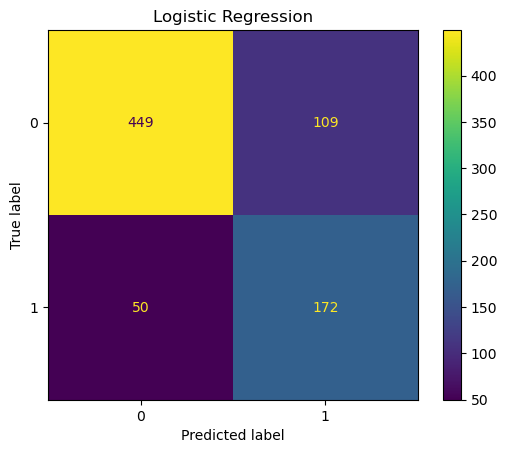

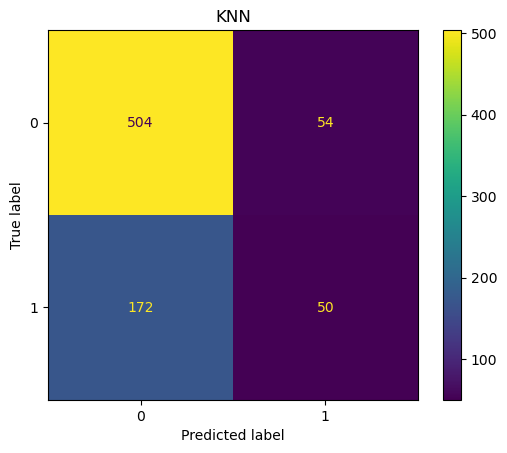

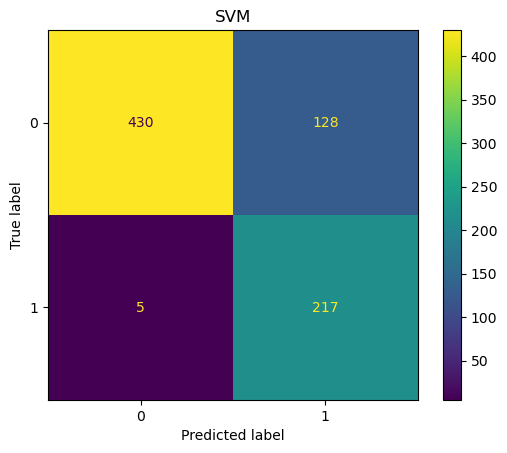

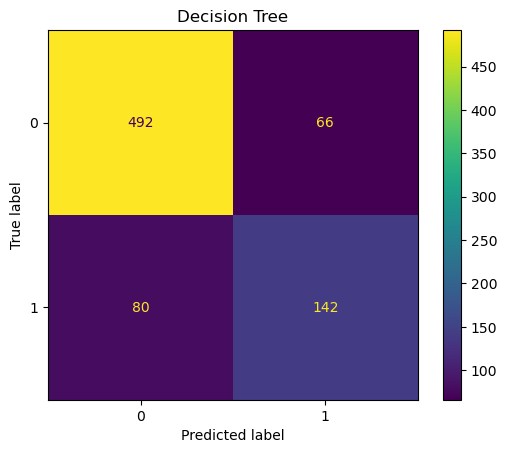

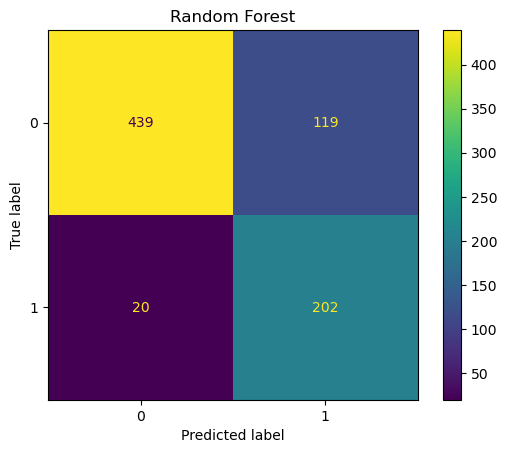

In [85]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

model_names = ["Logistic Regression", "KNN", "SVM", "Decision Tree", "Random Forest"]
model_objs = [lr, knn, svm, dt, rf]

for name, model in zip(model_names, model_objs):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot()
    plt.title(name)
    plt.show()

In [86]:
import pandas as pd

# Predictions from BEST model (SVM)
y_pred_best = svm.predict(X_test)

# Count elements in each category
counts = pd.Series(y_pred_best).value_counts()

print(counts)

0    435
1    345
Name: count, dtype: int64


In [182]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("shopping_behavior_updated.csv")

X = df[['Age', 'Purchase Amount (USD)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

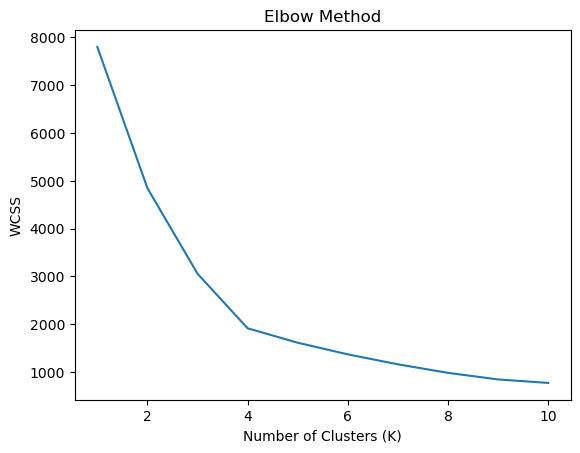

In [183]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

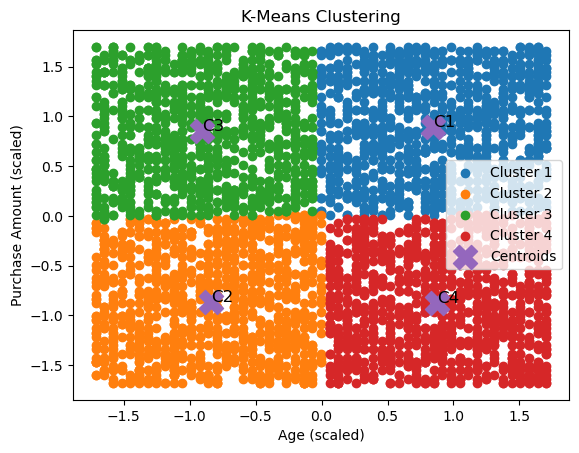

In [195]:
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

centers = kmeans.cluster_centers_

plt.figure()

# Plot clusters (start labels from 1)
for i in range(4):
    plt.scatter(
        X_scaled[labels == i, 0],
        X_scaled[labels == i, 1],
        label=f'Cluster {i+1}'
    )

# Plot centroid dots (center of each cluster)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=300,
    marker='X',
    label='Centroids'
)

# Add text labels on each centroid (C1, C2, C3, C4)
for i, center in enumerate(centers):
    plt.text(center[0], center[1], f'C{i+1}', fontsize=12)

plt.xlabel("Age (scaled)")
plt.ylabel("Purchase Amount (scaled)")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

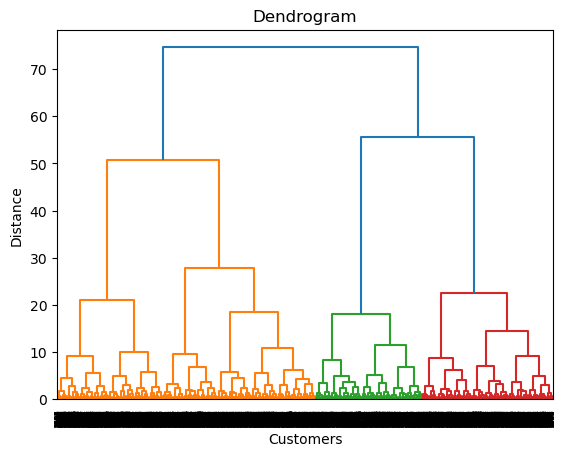

In [203]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure()
sch.dendrogram(sch.linkage(X_scaled, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

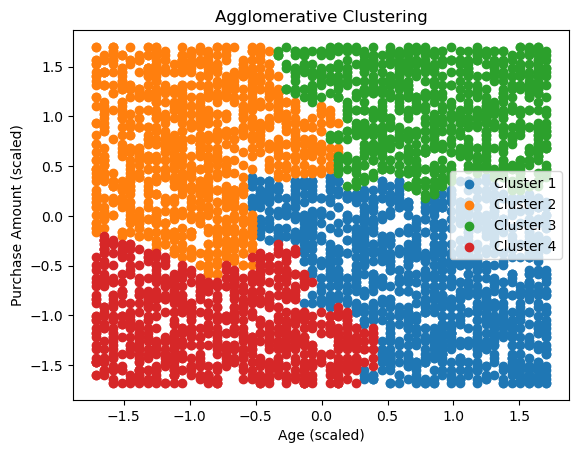

In [206]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_scaled)

plt.figure()

# Plot clusters
for i in range(4):
    plt.scatter(
        X_scaled[labels_agg == i, 0],
        X_scaled[labels_agg == i, 1],
        label=f'Cluster {i+1}'
    )

plt.xlabel("Age (scaled)")
plt.ylabel("Purchase Amount (scaled)")
plt.title("Agglomerative Clustering")
plt.legend()
plt.show()